# Day 013 · 假设检验入门
**Hypothesis Testing** · 阶段 P1 · 量化基础

> 你回测一个策略,过去三年年化 25%,跑赢沪深三百 8 个点——这是真本事还是运气?假设检验是量化里的'测谎仪',它给你一个具体数字 p 值,告诉你这个超额收益有多大概率纯属偶然。本节讲清三件事:① 零假设 H₀ 和备择假设 H₁ 的对立结构(假设它没用,看数据能不能推翻这个假设);② t 检验如何从样本均值/标准差/样本量算出 t 统计量,再查表得 p 值;③ p < 0.05 不是金科玉律,样本量、多次检验、p-hacking 会让 0.05 失效。我们用真实策略回测做 t 检验,跑 1000 次随机策略仿真演示 p-hacking,看为什么学术圈现在主张 p < 0.005。**学完你能用一个数字判断别人(或你自己)的策略是真本事还是赌运气**。

---

**课件生成日期:** 2026-05-05  ·  **建议学习时长:** 20 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 理解'零假设 H₀'和'备择假设 H₁'的对立结构,以及为什么先假设'没用'再去推翻
- 掌握 t 检验的三个输入(样本均值 / 样本标准差 / 样本量)和输出(t 统计量 + p 值)
- 会用 scipy.stats.ttest_1samp 一行做策略 t 检验,看 p 值判断显著性
- 知道 p < 0.05 不是金科玉律 — 样本量大时几乎什么都显著,小时几乎什么都不显著
- 理解多次检验陷阱(同时跑 100 个策略,5 个假阳性是必然的),以及 Bonferroni 修正
- 认识 p-hacking 的真实危害,以及学术界 2017 年后主张降到 p < 0.005 的原因

## 历史背景:Fisher、女士品茶 和 Renaissance 私房 30 年的统计纪律

1925 年英国统计学家 Ronald Fisher 在剑桥大学一个茶会上,听一位女士说她能仅凭口感判断'奶茶'是先倒奶还是先倒茶。Fisher 不信,但他设计了一个严谨的实验:8 杯茶,4 杯先奶 4 杯先茶,随机打乱顺序让她猜。如果她全猜对了,纯靠运气的概率是 1/70 ≈ 1.4%——Fisher 设定的'显著性阈值'是 5%,所以如果全对就承认她有此能力。结果她真的全对。Fisher 写进了 1935 年的《实验设计》一书,这就是**假设检验**的起源,也是 p < 0.05 这个数字第一次被人为定下来的地方。

**Renaissance Technologies(文艺复兴科技)** 是有史以来表现最好的对冲基金,Medallion 基金 1988-2018 年扣费前年化 66%。James Simons 团队的核心纪律就一条:**任何一个新策略上线之前,必须经过严格的统计显著性检验,t 统计量必须超过 5(对应 p < 0.0000005,比学术界标准严 100 万倍)**。这种近乎偏执的纪律让他们 30 年没有过任何一次年度亏损。

**LTCM 的反面案例**(Day 8 / Day 11 反复提)。LTCM 团队也做假设检验,但他们的样本是过去 5 年(平静期),没考虑'极端时段'这种本就罕见的事件。p 值算出来都很显著,实际上是把'平静期的稳定'当成了普遍真理——1998 俄罗斯违约一个事件,把整个统计基础掀翻。**统计显著不等于现实健壮,这是金融统计最贵的一课**。

**散户的真实场景**:你看到雪球大 V 晒'近三年策略胜率 65%',你心动了。但他从来没告诉你:他可能同时跑了 50 个策略,只把胜率最高的拿出来晒(典型 p-hacking)。如果你做 50 次随机策略,按 5% 显著性算,会有 2-3 个'看起来很厉害'纯粹是运气。

本节最重要的两句话:**先假设它没用,看数据能不能推翻**;**统计显著 ≠ 经济意义 ≠ 未来稳定**。

**关键人物:**
- Ronald Fisher(1925,假设检验之父,p < 0.05 起源)
- Jerzy Neyman & Egon Pearson(1933,Type I/II 错误概念,完善检验框架)
- James Simons / Renaissance(t > 5 严格门槛,30 年无年度亏损)
- Andrew Gelman(统计学家,2017 年带头主张降到 p < 0.005)
- John Ioannidis(2005 写《Why Most Published Research Findings Are False》)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 零假设 vs 备择假设:'先假设没用,看数据能不能推翻'

假设检验的核心结构:你不是直接证明'策略有效',而是先假设'**策略没用**'(零假设 H₀),然后看数据有多大概率支持这种'没用'。如果概率很低(比如 < 5%),就**拒绝 H₀**,接受备择假设 H₁。

**为什么这么绕?**因为'证明 X 真'比'证明 X 假'难得多。
类比:你想证明'天鹅都是白的',要看遍世界所有天鹅;但只要你看到一只黑天鹅,就能直接否定'天鹅都是白的'。
假设检验本质上是在找'反例'——找数据有多支持反例。

**应用到策略**:
H₀(零假设):策略平均收益 = 0(等价于'纯靠运气')
H₁(备择假设):策略平均收益 > 0(等价于'真有 alpha')
我们的工作是看数据是否能拒绝 H₀。如果拒绝不了,**不能说'策略没用'**,只能说'数据不足以证明策略有用'。

**经典误读**:'p > 0.05 → 策略没用'。错。p > 0.05 只是说'目前数据不足以证明它有用',可能是真没用,也可能是有用但样本太小看不出来。

```
H₀: μ = 0    vs    H₁: μ > 0    (单尾)    或    H₁: μ ≠ 0    (双尾)
```

> **举例:** 你的网格策略过去 252 天日均收益 +0.03%。H₀ 说真实日均 = 0,H₁ 说真实日均 > 0。如果数据让 H₀ 看起来很离谱(p 很小),你就敢上线;如果 H₀ 看起来仍可信(p 很大),你就不敢。


### 2. p 值:'纯靠运气至少出现这么好结果的概率'

**p 值定义**:假设 H₀ 是真的(也就是策略真的没用),那么纯靠运气至少出现这么好结果的概率有多大。

**直觉解读**:
p = 0.50 → 一半概率纯运气能跑出这种结果 → 完全没说服力
p = 0.10 → 10% 概率纯运气 → 边缘
p = 0.05 → 5% 概率纯运气 → Fisher 1925 年定的'显著'阈值,学术常用
p = 0.01 → 1% 概率纯运气 → 强显著
p = 0.001 → 0.1% 概率纯运气 → 极强
Renaissance 要求 t > 5 → p < 5×10⁻⁷ → 200 万分之一

**最常见的误读**(三大经典错误,面试常考):
❌ 'p = 0.05 意味着 H₀ 为真的概率是 5%' → **错**,p 是数据假设 H₀ 时的条件概率,不是 H₀ 的后验概率
❌ 'p < 0.05 意味着结果在重复实验中 95% 概率会重现' → **错**,这是 power(检验功效)的事
❌ '小 p 值意味着效应大' → **错**,p 小可能只是因为样本量大,效应可以仍然很小

正确理解:p 值是一个'警报阈值',不是'真理度量'。

```
p = P(observed_data | H₀ is true)    (条件概率,不是 H₀ 的真实概率)
```

> **举例:** 你回测得 p=0.03,意思是:如果策略真的没用,纯运气跑出至少这么好的结果概率仅 3%。这是低概率事件,所以你倾向于拒绝 H₀,认为策略可能有用。但**3% 不等于 0**,依然有 3% 概率你被运气欺骗了。


### 3. t 检验:三个输入算出一个 t 统计量

t 检验是最常用的假设检验,适用于'判断样本均值是否显著不同于零'。

**公式**:t = (x̄ - μ₀) / (s / √n),其中 x̄ 是样本均值,μ₀ 是 H₀ 假设的真值(通常是 0),s 是样本标准差,n 是样本量。

**直觉**:t 统计量本质是'信号 / 噪声'。
分子(x̄ - μ₀)= 信号(样本均值偏离零有多远)
分母(s / √n)= 噪声 / √n,样本量越大噪声越小
所以 |t| 越大 → 信号越强 / 噪声越小 → 越显著。

**算出 t 后查 p 值**:
t > 1.96 → p < 0.05(显著)
t > 2.58 → p < 0.01
t > 3.29 → p < 0.001
t > 5.00 → p < 5×10⁻⁷(Renaissance 标准)

**Python 一行**:`scipy.stats.ttest_1samp(returns, popmean=0)` 返回 (t, p)。简单到没朋友。

```
t = (x̄ - μ₀) / (s / √n)    自由度 df = n - 1
```

> **举例:** 策略 252 天日收益,样本均值 0.03%,样本标准差 1.0%,n=252。t = 0.0003 / (0.01/√252) = 0.0003 / 0.00063 ≈ 0.48。t 太小,p ≈ 0.32,不显著。想让 t 大,要么提高均值(增 alpha),要么降低 std(降波动),要么增加样本(更长回测)。


### 4. Type I / Type II 错误 + 检验功效(power)

假设检验的两种错误:
**Type I 错误(假阳性,α)**:H₀ 实际为真,但你错误拒绝它(误以为策略有用,其实没用)
**Type II 错误(假阴性,β)**:H₁ 实际为真,但你错误保留 H₀(放过一个真有用的策略)

p < 0.05 控制的是 α 水平(假阳性率)。但很多人忘了 β 也很重要——如果你的策略真的有 alpha 但样本太少没检测出来,你白白错过它。

**Power(检验功效)= 1 - β = '能正确发现真有用策略的概率'**。
Power 取决于:① 真实效应大小(alpha 越大越容易发现)② 样本量 ③ 显著水平 α。
经验:Power ≥ 0.80 才算够用,要达到这个水平在 alpha 小的金融场景里需要的样本量经常很大。

**实战**:1 年回测(252 天)对小 alpha 策略 power 通常很低,所以即使策略真有用也可能跑出 p > 0.05。学术界常用 3-5 年(750-1250 天)做权益策略 backtest,2 年是底线。

**对散户的启示**:别看到 p > 0.05 就轻易放弃策略,先算一下 power 够不够。如果 power 才 0.3,你只是没看到信号,不是没信号。

```
α = P(Type I) = 假阳性率    β = P(Type II) = 假阴性率    Power = 1 - β
```

> **举例:** 你想检测年化 alpha = 3% 的策略,日波动 1%。要达到 power=0.8,需要约 870 天样本。用 250 天回测 power 只有 0.45,意思是即使策略真的有用,你也只有 45% 概率发现。


### 5. 多次检验 + p-hacking + Bonferroni 修正

**多次检验陷阱**:你同时测 100 个策略,按 α=0.05,**纯运气会有大约 5 个假阳性**。这是数学必然 — 100 × 0.05 = 5。

**p-hacking** 是金融研究最大的瘟疫:
① 跑 1000 个不同参数的策略,只把 p 最小的报告
② 不停换样本期(2018-2020 不显著?换 2019-2021)直到出来一个 < 0.05
③ 加入特征 / 删除特征 / 调超参,直到结果好看

效果:看起来'统计显著'的论文 / 策略,实际可能只是大量尝试中的运气幸存者。Ioannidis 2005 那篇著名论文标题就叫《Why Most Published Research Findings Are False》。

**Bonferroni 修正**:同时做 m 个检验,把 α 阈值从 0.05 降到 0.05/m。
测 100 个策略 → 阈值 0.0005。这非常保守,不是最优修正(还有 FDR、Holm 等),但简单粗暴有效。

**学术界 2017 后主张 p < 0.005**(Benjamin et al., 2018 论文 'Redefine Statistical Significance')。理由:0.05 太松了,大量'显著结果'重现不了(replication crisis)。Renaissance 要 t>5 远比这严。

**散户实战**:① 在固定回测期(out-of-sample)只跑一次,不要换日期换参数
② 多个策略用 Bonferroni 或更现代方法(FDR)
③ 实盘前必须有 forward test(walk-forward)6 个月以上
④ p-value 不是唯一证据,要看经济直觉

```
Bonferroni 修正:α_corrected = α / m,  m = 检验次数
```

> **举例:** 你跑 50 个不同因子做选股,每个都做 t 检验。按 α=0.05 你会期待 2-3 个假阳性。Bonferroni 修正后阈值 = 0.05/50 = 0.001,只有 t > 3.3 的因子才能进入下一轮。


## 实操:策略 t 检验 + 多次检验仿真 + 真实回测显著性

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


[*********************100%***********************]  1 of 1 completed


=== 沪深三百 20 日均线策略 t 检验 ===
     指标         数值
 样本量(天) 723.000000
日均收益(%)   0.024327
  年化(%)   6.130464
 Sharpe   0.444699
  t 统计量   0.753242
    p 值   0.451550

判断:不显著(可能纯运气)(α=0.05)

=== 1000 个随机策略多次检验 ===
按 α=0.05 假阳性数 = 45(理论 50)
Bonferroni 修正(α=0.00005)假阳性数 = 0

=== p-hacking 演示:同一策略,换不同回测窗口 ===
最小 p 值 = 0.0132 (在 58 个窗口中)
按 α=0.05 数 = 2/58
⚠ 只报告最小 p 值就是 p-hacking,真实显著性远低于这个数字

✓ 图已保存到 day013_hypothesis.png


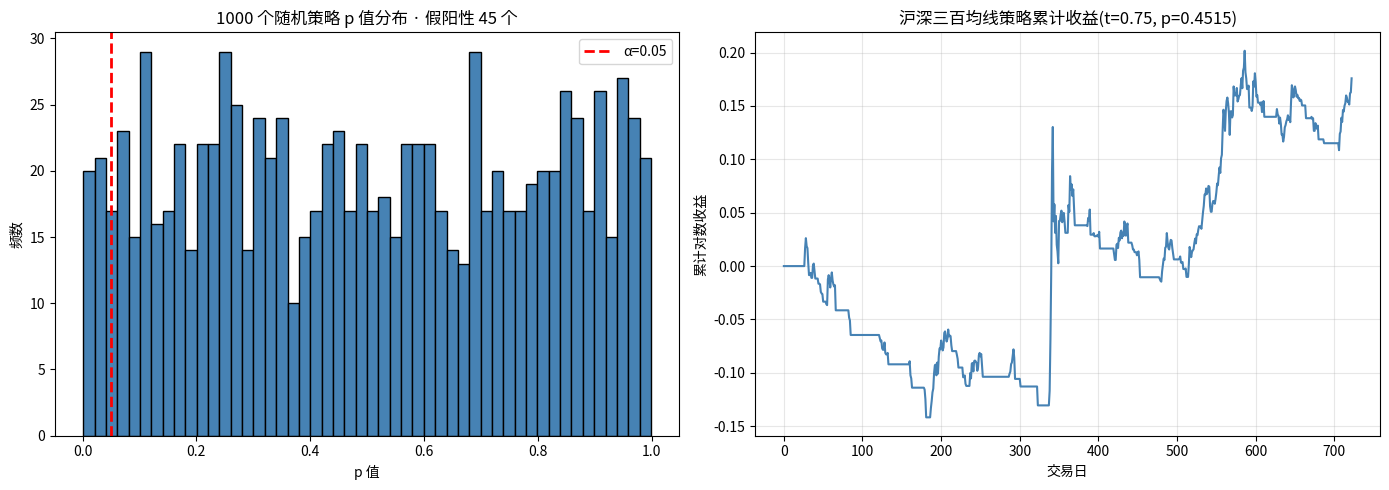

In [2]:
# day_013_hypothesis.py — 假设检验在量化策略中的实战
import numpy as np, pandas as pd, yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt

# ============ 1. 真实策略 t 检验:沪深三百均线策略 ============
px = yf.download('510300.SS', period='3y', auto_adjust=True)['Close'].squeeze()
ret = px.pct_change().dropna()

# 简单均线策略:20 日均线上买入持有,下穿空仓
ma20 = px.rolling(20).mean()
signal = (px > ma20).shift(1).fillna(False).astype(int)
strat_ret = (signal * ret).dropna()

# t 检验:H₀ = 策略日均收益 = 0
t_stat, p_val = stats.ttest_1samp(strat_ret, popmean=0)
n = len(strat_ret)
annualized = strat_ret.mean() * 252
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252)

result = pd.DataFrame({
    '指标': ['样本量(天)','日均收益(%)','年化(%)','Sharpe','t 统计量','p 值'],
    '数值': [n, strat_ret.mean()*100, annualized*100, sharpe, t_stat, p_val],
})
print('=== 沪深三百 20 日均线策略 t 检验 ===')
print(result.to_string(index=False))
verdict = '显著' if p_val < 0.05 else '不显著(可能纯运气)'
print(f'\n判断:{verdict}(α=0.05)')

# ============ 2. 多次检验仿真:1000 个随机策略,看几个'假阳性' ============
np.random.seed(42)
n_strategies, n_days = 1000, 252
p_values = []
for _ in range(n_strategies):
    fake_ret = np.random.normal(0, 0.01, n_days)  # 真实 mean=0
    _, p = stats.ttest_1samp(fake_ret, 0)
    p_values.append(p)
p_values = np.array(p_values)

false_positives = (p_values < 0.05).sum()
bonferroni = (p_values < 0.05/n_strategies).sum()
print(f'\n=== 1000 个随机策略多次检验 ===')
print(f'按 α=0.05 假阳性数 = {false_positives}(理论 50)')
print(f'Bonferroni 修正(α=0.00005)假阳性数 = {bonferroni}')

# ============ 3. p-hacking 演示:换 50 个回测期 ============
print(f'\n=== p-hacking 演示:同一策略,换不同回测窗口 ===')
windows = [(strat_ret.iloc[i:i+150]) for i in range(0, len(strat_ret)-150, 10)]
p_per_window = [float(stats.ttest_1samp(w, 0).pvalue) for w in windows if len(w)==150]
min_p_w = min(p_per_window)
print(f'最小 p 值 = {min_p_w:.4f} (在 {len(p_per_window)} 个窗口中)')
print(f'按 α=0.05 数 = {sum(p<0.05 for p in p_per_window)}/{len(p_per_window)}')
print(f'⚠ 只报告最小 p 值就是 p-hacking,真实显著性远低于这个数字')

# ============ 4. 可视化:p 值分布 ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(p_values, bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
axes[0].set_title(f'1000 个随机策略 p 值分布 · 假阳性 {false_positives} 个')
axes[0].set_xlabel('p 值'); axes[0].set_ylabel('频数'); axes[0].legend()

axes[1].plot(strat_ret.cumsum().values, color='steelblue')
axes[1].set_title(f'沪深三百均线策略累计收益(t={t_stat:.2f}, p={p_val:.4f})')
axes[1].set_xlabel('交易日'); axes[1].set_ylabel('累计对数收益')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('day013_hypothesis.png', dpi=120)
print('\n✓ 图已保存到 day013_hypothesis.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| Renaissance Medallion(30 年无年度亏损) | 私募基金内部纪律 | James Simons 团队所有新策略上线必须 t > 5(p < 5×10⁻⁷)。比学术 0.05 严 100 万倍。30 年扣费前年化 66%,从未年度亏损,靠的就是这个近乎偏执的统计纪律 + 大样本 + 跨策略组合。 |
| 学术界 Replication Crisis | 心理学 / 医学 / 经济学 | 2015 年 Reproducibility Project 重做 100 篇心理学顶刊论文,只有 36 篇能复现原结果。p-hacking + 多次检验 + 出版偏差是元凶。金融论文也好不到哪去,Harvey/Liu 2014 估计学术金融文献假阳性率 30%+。 |
| LTCM 1998 (反面案例) | Long-Term Capital Management | 诺奖团队的策略每个 t > 3(高显著)。但样本只有 4-5 年平静期,没考虑'极端时段'。统计上显著 + 现实中脆弱 = 几个月亏 90%。**统计显著 ≠ 经济稳健**。 |
| 雪球大 V 晒单 | 散户实战陷阱 | 大 V 说'近一年策略胜率 65%',你心动。但他没说同时跑了 50 个变体,只把胜率最高的拿出来 — 典型 p-hacking。对照:50 个随机策略按 α=0.05 期望 2-3 个'看起来很厉害',就是这种。 |
| Sharpe 比率 + t 统计量的关系 | 回测显著性快速估算 | 对日数据,t = Sharpe × √n / √252。意思是:Sharpe=1.0 + 252 天 → t≈1.0(不显著);Sharpe=1.0 + 1000 天 → t≈2.0(边缘);Sharpe=1.5 + 1000 天 → t≈3.0(显著)。**所以 Sharpe < 1 + 短回测期 = 不要相信任何单一回测结果**。 |


## 常见坑

### ⚠ 01. 把 p > 0.05 当成'策略没用'

p > 0.05 只意味着'数据不足以拒绝 H₀',可能真没用,也可能有用但样本太小。正确做法:看 power(检验功效),如果 power 才 0.3,你只是没看到信号,不是没信号。策略的 Sharpe 可能合理,但需要更长样本来确认。

### ⚠ 02. p-hacking — 跑 100 个策略只报最好的

1000 个随机策略按 α=0.05,期望 50 个假阳性。如果你只挑 p 最小的报告,你的报告就是这 50 个幸运者之一。雪球大 V / 量化论文 / 私募市场介绍材料里大量存在这种。做研究必须固定计划 + 预先注册检验方案 + 用 Bonferroni 或 FDR 修正。

### ⚠ 03. 样本量决定一切 — 别拿 1 个月数据下结论

n=20 的样本算 t 检验完全不可信,因为分母 √n 让噪声极大。金融策略最少 1 年(252 天),稳健需要 3-5 年(750-1250 天)。Renaissance 用 30 年数据 + 跨策略 + 大样本,所以才敢做出 t > 5 的判断。

### ⚠ 04. 统计显著 ≠ 经济意义

样本量足够大时,即使 0.001% 的微小 alpha 也能显著(t > 5)。但 0.001%/天年化 0.25%,扣掉手续费 / 滑点 / 税 后实际为负。实战要看 effect size(收益绝对值)+ 显著性,两者都重要。p 值告诉你'是不是运气',收益数字告诉你'值不值得做'。

### ⚠ 05. 正态假设失效时 t 检验也失效

t 检验假设残差近似正态。但金融数据 Day 10/11 讲过——尾巴极厚。极端日会让 t 统计量被几次大涨/大跌主导,p 值不可信。替代方案:① bootstrap 重抽样(无分布假设)② 学生 t 分布 + robust SE ③ 永远画 Q-Q 图先看分布。

## 实战 SOP · 假设检验实战 SOP

1. 策略上线前必做 t 检验 + 看 p 值,Sharpe 单独不够
2. α=0.05 是底线,严肃量化用 0.01 或更严(Renaissance t>5)
3. 样本量最少 252 天(1 年),稳健 3-5 年,小于 6 个月不做结论
4. 多策略同时测必须 Bonferroni 或 FDR 修正
5. 做研究先写检验方案,不要数据看完再决定方向(避免 p-hacking)
6. p 值 + effect size 都要看,统计显著 ≠ 经济显著
7. 正态假设可疑时用 bootstrap 或 robust SE 替代 t 检验

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 假设检验结构:先假设'没用'(H₀),看数据能否推翻它,推翻就接受备择假设(H₁)。
3. p 值是'纯运气至少出现这么好结果的概率',不是 H₀ 为真的概率。
4. t 检验:t = (x̄ - μ₀) / (s / √n),信号 / 噪声,|t| 大 → p 小 → 显著。
5. α=0.05 是 1925 年 Fisher 拍脑袋定的;Renaissance 用 t>5(p<5×10⁻⁷)严 100 万倍。
6. Type I 错误(假阳性 α)常被关注,Type II(假阴性 β)和 power(1-β)也很重要。
7. 多次检验陷阱:跑 100 个策略期望 5 个假阳性。必须 Bonferroni 或 FDR 修正。
8. p-hacking 三种典型:多策略只报最好 / 换样本期 / 调参直到显著。学术界 30% 论文有此嫌疑。
9. 统计显著 ≠ 经济显著 ≠ 未来稳健 — LTCM 输光就是因为忘了第三件。

## 自测题

**Q1.** 你回测一个策略 252 天,Sharpe=0.8,t 统计量大约多少?p 值大约多少?显著吗?

**Q2.** 解释:为什么 Renaissance 用 t>5 而不是学术界的 t>1.96?这两个数对应的概率分别是多少?

**Q3.** 你看到一篇量化论文报告 p=0.03,他们测了 50 个因子,只报告这一个。Bonferroni 修正后这个 p 还显著吗?

**Q4.** p-hacking 的三种典型形式是什么?你自己做研究怎么防止?

**Q5.** 举一个'统计上显著但经济上没意义'的真实例子。这告诉我们 p 值和什么必须一起看?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 014 · R² 与策略评估** (R-squared in Strategies)

Day 14:R² 与策略评估 — Day 9 讲过 R² 是回归方程的解释力,这一节专门讲 R² 在策略评估里的应用 / 局限 / 陷阱,以及 Adjusted R²、out-of-sample R² 这两个更可靠的版本。

## 推荐阅读

- Fisher《The Design of Experiments》(1935)— 假设检验经典,p<0.05 的源头
- Ioannidis《Why Most Published Research Findings Are False》(PLOS Medicine, 2005)— 统计学最被引用论文
- Benjamin et al.《Redefine Statistical Significance》(Nature Human Behaviour, 2018)— 主张 α 降到 0.005
- Harvey/Liu/Zhu《...and the Cross-Section of Expected Returns》(2016)— 金融因子假阳性率分析
- scipy.stats 文档 + statsmodels.stats.multitest — Python 量化标配